# Customer Review Sentiment Analyzer — Training Notebook (3-Class)

Trains a TF-IDF + Logistic Regression model to classify reviews as
**positive / neutral / negative**, and saves it to `../models/`.

**Dataset:** `data/raw/amazon_reviews.csv`
**Columns used:** `reviewText` (review text), `overall` (numeric star rating 1–5)
Other columns in the file (`day_diff`, `helpful_yes`, `helpful_no`, `total_vote`,
`score_pos_neg_diff`, `score_average_rating`, `wilson_lower_bound`) are about
review-helpfulness voting and are not used for sentiment classification.

Uses shared preprocessing functions from `../utils.py` so training and the
Streamlit app (`../app.py`) always use identical logic.


## Step 1: Project Setup & Data Acquisition

### 1.1 Imports

In [1]:
import os
import sys

# Find the project root regardless of the kernel's working directory
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
else:
    PROJECT_ROOT = cwd

sys.path.append(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from utils import preprocess, LABEL_MAP, LABEL_MAP_INV

print("Imports ready.")

Project root: c:\Users\dell\Desktop\Customer-Review-Sentiment-Analyzer
Imports ready.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### 1.2 Load Dataset

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "amazon_reviews.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (4915, 12)


,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


### 1.3 Build Working Columns

`reviewText` is already a single text column and `overall` is already a clean
numeric rating (1.0–5.0) — no combining or regex needed here.


In [3]:
df['review'] = df['reviewText'].fillna('')
df['rating_num'] = df['overall']

print(df[['overall', 'rating_num']].head())
print("\nMissing ratings:", df['rating_num'].isna().sum())
print("Missing review text:", df['review'].eq('').sum())


   overall  rating_num
0      4.0         4.0
1      5.0         5.0
2      4.0         4.0
3      5.0         5.0
4      5.0         5.0

Missing ratings: 0
Missing review text: 1


### 1.4 Derive the 3-Class Sentiment Label from Rating

In [4]:
def rating_to_sentiment(r):
    if pd.isna(r):
        return np.nan
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating_num'].apply(rating_to_sentiment)

# Drop any rows where rating or review text is missing
df = df[df['review'].str.strip() != ''].copy()
df = df.dropna(subset=['sentiment']).reset_index(drop=True)

print(df['sentiment'].value_counts())
print("\nTotal usable rows:", len(df))


sentiment
positive    4448
negative     324
neutral      142
Name: count, dtype: int64

Total usable rows: 4914


### 1.5 Exploratory Data Analysis (EDA)

C:\Users\dell\AppData\Local\Temp\ipykernel_11408\3688586045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, order=['negative','neutral','positive'], palette='viridis')


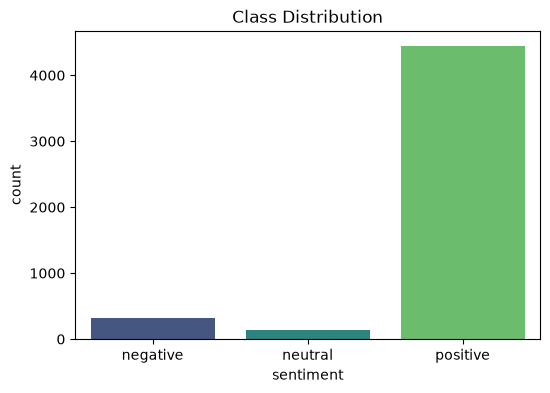

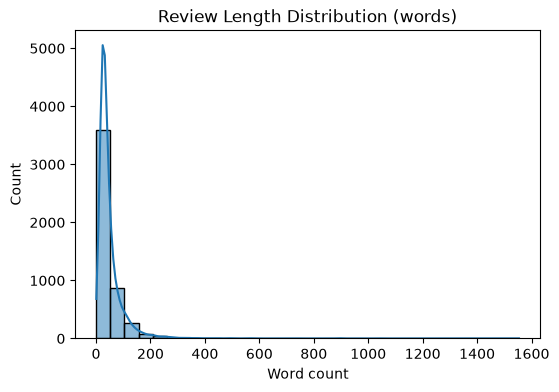

,review,sentiment
3691,you cant beat the price and it works great . I...,positive
1272,I recently upgrade my cellphone to the Samsung...,positive
4823,Fast! Reliable! Huge storage. Already own 2 fo...,positive
3500,Fast. Sleek. Small. Not really much to say abo...,positive
957,It works just fine and I'm thinking of getting...,positive


In [5]:
# Class balance
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, order=['negative','neutral','positive'], palette='viridis')
plt.title('Class Distribution')
plt.show()

# Review length distribution
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=30, kde=True)
plt.title('Review Length Distribution (words)')
plt.xlabel('Word count')
plt.show()

df[['review','sentiment']].sample(5, random_state=1)


> **Note:** Amazon-style ratings usually skew heavily positive (lots of 4–5★
> reviews). If `neutral` (3★) looks like a small slice above, that's expected —
> not a bug. Step 3 uses `class_weight='balanced'` to compensate.

## Step 2: Data Preprocessing & Feature Engineering

### 2.1 Clean & Preprocess Text
Uses `preprocess()` from `utils.py` — the exact same function `app.py` will
call at prediction time.


In [6]:
df['clean_review'] = df['review'].apply(preprocess)
df[['review', 'clean_review', 'sentiment']].head()


,review,clean_review,sentiment
0,No issues.,issue,positive
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...,positive
2,it works as expected. I should have sprung for...,work expected sprung higher capacity think mad...,positive
3,This think has worked out great.Had a diff. br...,think worked great diff bran gb card went sout...,positive
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...,positive


### 2.2 Encode Labels (3 classes)

In [7]:
df['label'] = df['sentiment'].map(LABEL_MAP)
df[['sentiment', 'label']].drop_duplicates()


,sentiment,label
0,positive,2
11,neutral,1
32,negative,0


### 2.3 TF-IDF Vectorization

In [8]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

print("Feature matrix shape:", X.shape)


Feature matrix shape: (4914, 10000)


## Step 3: Model Training & Evaluation

### 3.1 Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 3931 | Test size: 983


In [10]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("Resampled training class counts:", pd.Series(y_train).value_counts().to_dict())

Resampled training class counts: {2: 3558, 0: 3558, 1: 3558}


### 3.2 Train Logistic Regression (3-class)

compensates for `neutral` usually being the
smallest class in ratings-derived data.


In [11]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {model.score(X_test, y_test):.4f}")


Train accuracy: 0.9956
Test accuracy:  0.9318


### 3.3 Hyperparameter Tuning (GridSearchCV over C)

In [12]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV F1-macro:", grid.best_score_)

best_model = grid.best_estimator_


Best C: {'C': 10}
Best CV F1-macro: 0.9930545300605903


In [13]:
for word in ['hate', 'bad', 'worse', 'worst', 'terrible', 'awful', 'disappointed']:
    print(word, '-> in vocabulary:', word in tfidf.vocabulary_)

hate -> in vocabulary: True
bad -> in vocabulary: True
worse -> in vocabulary: True
worst -> in vocabulary: True
terrible -> in vocabulary: True
awful -> in vocabulary: False
disappointed -> in vocabulary: True


In [ ]:
target_names = list(LABEL_MAP.keys())  # ['negative', 'neutral', 'positive']

for word in ['hate', 'bad', 'worse', 'worst', 'terrible', 'product']:
    idx = tfidf.vocabulary_[word]
    coefs = best_model.coef_[:, idx]
    print(f"{word:12s} -> negative: {coefs[0]:+.3f}  neutral: {coefs[1]:+.3f}  positive: {coefs[2]:+.3f}")

### 3.4 Evaluate on Test Set

Test Accuracy: 0.9348931841302136

              precision    recall  f1-score   support

    negative       0.78      0.65      0.71        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.99      0.97       890

    accuracy                           0.93       983
   macro avg       0.58      0.54      0.56       983
weighted avg       0.91      0.93      0.92       983



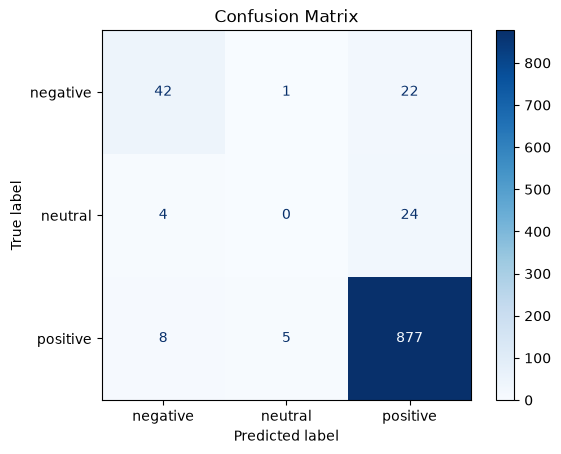

In [14]:
y_pred = best_model.predict(X_test)
target_names = list(LABEL_MAP.keys())   # ['negative', 'neutral', 'positive']

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


### 3.5 Save the Trained Model & Vectorizer

Saved to `../models/` using `pickle` so `app.py` at the project root can
load them directly.


In [15]:
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, "sentiment_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

with open(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf, f)

print("Saved model files to:", MODEL_DIR)

Saved model files to: c:\Users\dell\Desktop\Customer-Review-Sentiment-Analyzer\models


## Step 4: Application Development & Integration

### 4.1 Reusable Prediction Function (Quick Check)

In [16]:
from utils import predict_sentiment

print(predict_sentiment("This product is absolutely wonderful, I love it!", best_model, tfidf))
print(predict_sentiment("It's okay, does the job but nothing special.", best_model, tfidf))
print(predict_sentiment("Terrible, broke after one day, complete waste of money.", best_model, tfidf))


{'text': 'This product is absolutely wonderful, I love it!', 'sentiment': 'positive', 'confidence': 0.9941}
{'text': "It's okay, does the job but nothing special.", 'sentiment': 'positive', 'confidence': 0.9778}
{'text': 'Terrible, broke after one day, complete waste of money.', 'sentiment': 'negative', 'confidence': 0.5372}


### 4.2 Web App (Streamlit)

`app.py` at the project root loads `models/sentiment_model.pkl` and
`models/tfidf_vectorizer.pkl` and serves live predictions. To run it, go
back to the project root in your terminal:
```bash
streamlit run app.py
```


## Summary

| Step | What was done |
|------|----------------|
| 1 | Loaded `amazon_reviews.csv`, used `reviewText` directly and `overall` as the numeric rating, derived 3-class label |
| 2 | Cleaned text (HTML/punctuation/lowercasing), tokenized, removed stopwords, lemmatized, TF-IDF vectorized |
| 3 | Trained Logistic Regression with `class_weight='balanced'`, tuned `C` via GridSearchCV, evaluated with precision/recall/F1/confusion matrix, saved model with `pickle` |
| 4 | Verified `predict_sentiment()` and connected the saved model to the Streamlit app |
